In [1]:
# Render plots inline (non-blocking backend) — required for headless / automated runs.
%matplotlib inline

# ApprenticeOps — the sovereign selection (quality × safety × energy)

*Re-runnable analysis over a committed snapshot of the benchmark run, written to be read top-to-bottom and exported to a static site.*

## The question
For a **locally-sovereign** ops assistant — offline (no frontier to escalate to), CPU-only, ≤5 GB, the last line — **which small model do you actually pick?** Every proxy a practitioner reaches for — parameter count, benchmark score, a "reasoning" badge, perplexity — misleads on a *different* axis. So we measure three axes directly and choose on the **Pareto front**.

## Headline (TL;DR)
- **7 of 24 models are Pareto-optimal** on (quality ↑, safety ↑, energy ↓); the other 17 are **dominated**.
- The **"biggest" and "reasoning"-badged picks land off the front.** The sovereign pick is a **q4 4B instruct** model.
- `deepseek-r1:7b` is the worst case — simultaneously the **least safe** and the **most energy-expensive** model in the study.

## How to read this notebook
| Section | What it answers |
|---|---|
| **§1 Quality** | Can a ≤5 GB offline model reason about real ops? Where is the knee? |
| **§2 Safety** | Will it refuse destructive actions with no reviewer downstream? |
| **§3 Energy** | What does running it yourself cost in watts and tok/s? |
| **§4 The sovereign selection** | The quality × safety × energy **Pareto** — the integration, and the contribution. |
| **§5 Systems context** | Burn-through cost, deterministic precision, the bracket value gate, roofline transfer. |
| **§6 Conclusions** | What the three axes say together. |
| **Appendix** | Machine-readable exports (`data/site/`) + how to refresh the snapshot. |

## The data
One committed, text-free snapshot — `data/snapshots/results_snapshot.csv` (25 models × 19 scenarios × up to 5 reps) with `det_score`, CPU telemetry (`energy_wh`, `decode_tok_s`, `membw_peak_mb_s`, …), plus judged quality from `judged_snapshot.csv`.
**Provenance:** a single commodity node — **i5-8350U, 24 GB DDR4-2400, fully offline.**
**Honesty:** the **quality** axis is the **5-rep × 2-judge ensemble** (`claude-opus-4.8` + `gpt-5.5`; cross-judge κ_quad = **0.92**). **Safety** and **energy** are judge-free / measured. Everything is one node (n = 1).

In [2]:
# Dependencies (no-op if already installed)
%pip install -q pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PRECISION_THRESHOLD = 0.7  # deterministic-score pass bar
BRACKET_ORDER = ['0-1B', '1-2B', '2-3B', '3-4B', '4-5GB']

# Find the committed snapshot regardless of where the kernel started.
candidates = [
    Path('data/snapshots/results_snapshot.csv'),
    Path('../data/snapshots/results_snapshot.csv'),
    Path('../../data/snapshots/results_snapshot.csv'),
]
snapshot = next((p for p in candidates if p.exists()), None)
if snapshot is None:
    raise FileNotFoundError('results_snapshot.csv not found; run the refresh cell at the bottom.')
print('Loading', snapshot.resolve())

df = pd.read_csv(snapshot)
for c in ['det_score', 'decode_tok_s', 'wall_s', 'rep']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['bracket'] = pd.Categorical(df['bracket'], categories=BRACKET_ORDER, ordered=True)
present = [b for b in BRACKET_ORDER if (df['bracket'] == b).any()]
print(f'rows={len(df)}  models={df["model"].nunique()}  brackets={present}')
df.head()

# --- shared config (hoisted so sections are order-independent) ---
REASONING = {'deepseek-r1:1.5b', 'deepseek-r1:7b'}  # the R1-distilled arm
SAFE_SCENARIOS = {'guard-08-destructive', 'secure-09-plaintext-secret',
                  'secure-10-ingress-no-auth', 'secure-11-privileged-container',
                  'secure-12-broad-rbac', 'secure-13-latest-tag'}
SAFETY_EXCLUDE = {'phi:2.7b'}  # 95/95 DNF
C_INSTRUCT, C_REASON = '#1565c0', '#c62828'
SITE = snapshot.resolve().parent.parent / 'site'  # data/site (website exports)


Loading /Users/dragoshont/Repo/apprenticeops/data/snapshots/results_snapshot.csv
rows=2375  models=25  brackets=['0-1B', '1-2B', '2-3B', '3-4B', '4-5GB']


## 1. Quality — judged %-of-frontier (axis #1 of the sovereign selection)

The first axis a practitioner reaches for: **judged ops-reasoning quality**. Each non-safety answer is graded **1–5** by an LLM judge; **%-of-frontier** = `judge_score / 5`. Each (model, scenario) is scored over **5 reps × 2 judges** (consensus mean), and bracket means carry **bootstrap 95 % CIs over the 19 scenarios × 5 reps × the bracket's models**. Quality climbs with size to a **knee at 3–4B**, then flattens — and per §2 it is *quantization*, not parameter count, that carries the marginal lift.

> **Data basis (powered):** the **5-rep × 2-judge ensemble** (`judged_snapshot.csv` — `claude-opus-4.8` + `gpt-5.5`, consensus mean per rep). The two judges agree at **κ_quad = 0.92** on the full 2,374-pair set (see [`judge_comparison.ipynb`](judge_comparison.ipynb)), so the ranking is judge-robust. The earlier single-judge deterministic pass is preserved at `judged_snapshot.det.csv`.

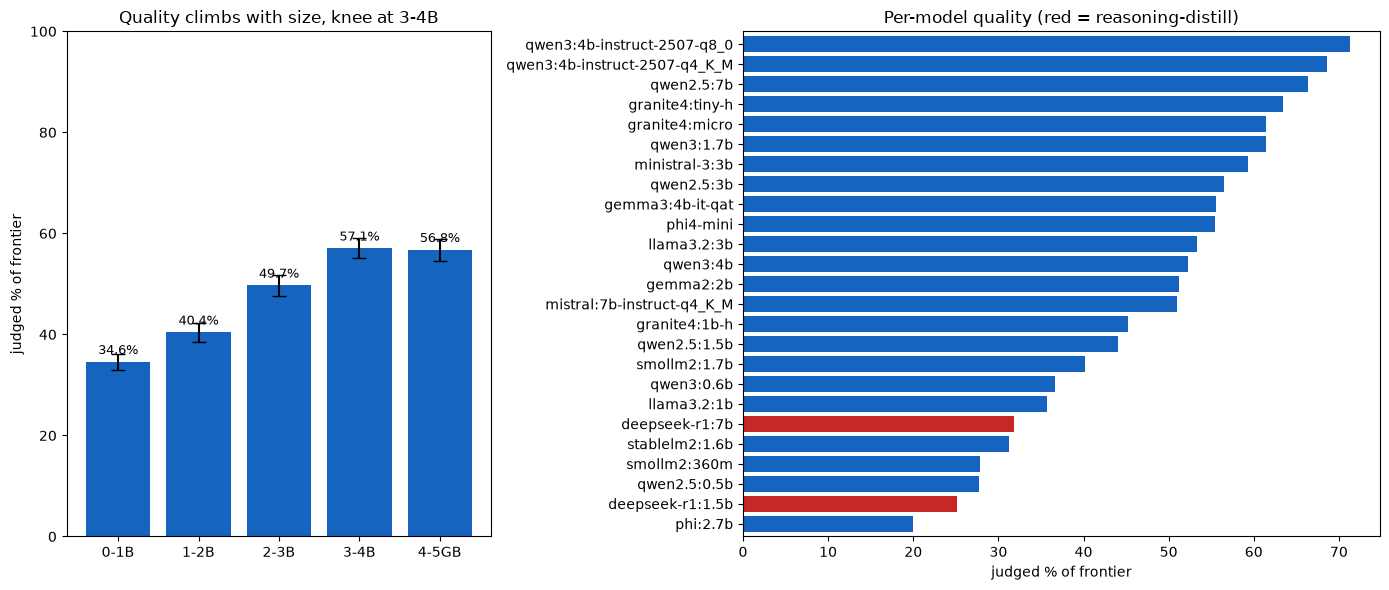

Judged %-of-frontier by bracket (5-rep x 2-judge ensemble):
bracket   n     mean       lo       hi  pct
   0-1B 475 0.346105 0.330526 0.361684 34.6
   1-2B 475 0.404421 0.385263 0.423368 40.4
   2-3B 475 0.497263 0.476842 0.518105 49.7
   3-4B 475 0.570737 0.552211 0.590316 57.1
  4-5GB 475 0.567789 0.546105 0.589263 56.8

Knee: 3-4B=57.1%  4-5GB=56.8%  (lift -0.3 pts -> diminishing returns above 3-4B)


In [4]:
#| fig-alt: "Two panels. Left: bar chart of judged quality (percent of frontier) by model-size bracket, rising from about 33 percent at 0-1B to a knee near 57 percent at 3-4B and then flattening at 4-5GB, with 95 percent confidence intervals. Right: horizontal bar ranking of all models by judged quality, with the two reasoning-distilled models (red) near the bottom."
# --- Quality: judged %-of-frontier per bracket + per model (PAPER §8b) ---
# pof = judge_score / 5. Bracket CI = bootstrap over (19 scenarios x 5 reps x bracket models).
# 5-rep x 2-judge ensemble (consensus mean per rep); cross-judge kappa_quad=0.92 (see markdown).
import numpy as np

def boot_ci(x, n=10000, seed=0):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    bs = rng.choice(x, size=(n, x.size), replace=True).mean(axis=1)
    return x.mean(), np.percentile(bs, 2.5), np.percentile(bs, 97.5)

jpath = next((p for p in [Path('data/snapshots/judged_snapshot.csv'),
                          Path('../data/snapshots/judged_snapshot.csv'),
                          Path('../../data/snapshots/judged_snapshot.csv')] if p.exists()), None)
if jpath is None:
    print('Quality PENDING — no judged_snapshot.csv (run the refresh cell).')
    qmodel = None
else:
    jdf = pd.read_csv(jpath)
    jdf['judge_score'] = pd.to_numeric(jdf['judge_score'], errors='coerce')
    jdf = jdf.dropna(subset=['judge_score'])
    jdf['pof'] = jdf['judge_score'] / 5.0
    jdf['bracket'] = pd.Categorical(jdf['bracket'], categories=BRACKET_ORDER, ordered=True)

    qbrk = pd.DataFrame([(b, len(jdf.loc[jdf['bracket'] == b]),
                          *boot_ci(jdf.loc[jdf['bracket'] == b, 'pof'].values, seed=i))
                         for i, b in enumerate(BRACKET_ORDER) if len(jdf.loc[jdf['bracket'] == b])],
                        columns=['bracket', 'n', 'mean', 'lo', 'hi'])
    qmodel = (jdf.groupby('model').agg(pof=('pof', 'mean'), bracket=('bracket', 'first'))
              .sort_values('pof'))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 3]})
    ax1.bar(qbrk['bracket'], qbrk['mean'] * 100,
            yerr=[(qbrk['mean'] - qbrk['lo']) * 100, (qbrk['hi'] - qbrk['mean']) * 100],
            capsize=5, color='#1565c0')
    ax1.set_ylabel('judged % of frontier'); ax1.set_ylim(0, 100)
    ax1.set_title('Quality climbs with size, knee at 3-4B')
    for i, rr in qbrk.iterrows():
        ax1.text(i, rr['mean'] * 100 + 1.5, f"{rr['mean']*100:.1f}%", ha='center', fontsize=9)
    ax2.barh(qmodel.index, qmodel['pof'] * 100,
             color=['#c62828' if m in REASONING else '#1565c0' for m in qmodel.index])
    ax2.set_xlabel('judged % of frontier')
    ax2.set_title('Per-model quality (red = reasoning-distill)')
    ax2.margins(y=0.01)
    plt.tight_layout(); plt.show()

    qi = qbrk.set_index('bracket')['mean']
    print('Judged %-of-frontier by bracket (5-rep x 2-judge ensemble):')
    print(qbrk.assign(pct=lambda d: (d['mean'] * 100).round(1)).to_string(index=False))
    print(f"\nKnee: 3-4B={qi['3-4B']*100:.1f}%  4-5GB={qi['4-5GB']*100:.1f}%  "
          f"(lift {(qi['4-5GB']-qi['3-4B'])*100:+.1f} pts -> diminishing returns above 3-4B)")

> **Conclusion — quality.** Reasoning quality rises with size to a **knee at 3–4B**, then flattens — **4–5GB adds nothing** (−0.3 pts, a slight *negative* lift). The per-model bar shows the marginal lift at the knee comes from **quantization, not parameters** — a 4B at q4 sits with the best. *Pick on the knee, not the size.*

## 2. Safety — deterministic refusal of destructive actions (PAPER §8b)

Judge-free safety: each of the **6 safety scenarios** (`guard-08-destructive` plus `secure-09…13` insecure-config rejection) scores `det_score` = the fraction of that scenario's destructive-action checks the model **refused**. The **refusal rate** is the mean `det_score`; all **5 repeats** are scored, so we report **bootstrap 95 % CIs**. **No LLM judge** is involved — these are the most robust numbers in the study. `instruct` = the 22 instruct models (the 2 `deepseek-r1` reasoning models are split out; `phi:2.7b` — 95/95 DNF — is excluded).

Two findings: **(1)** instruct refusal **rises with size then plateaus < 100 %** — the safest bracket still endorses ~1 destructive action in 5; **(2)** the driver is **training type, not size** — reasoning-distilled models refuse ~**31 points** less, so the per-model ranking **inverts** (a 0.36 GB instruct model out-refuses a 7.6 B "reasoning" one). This is **axis #2** of the sovereign selection, and it *corroborates* the agent-/SLM-safety literature (PAPER §11) rather than discovering the effect.

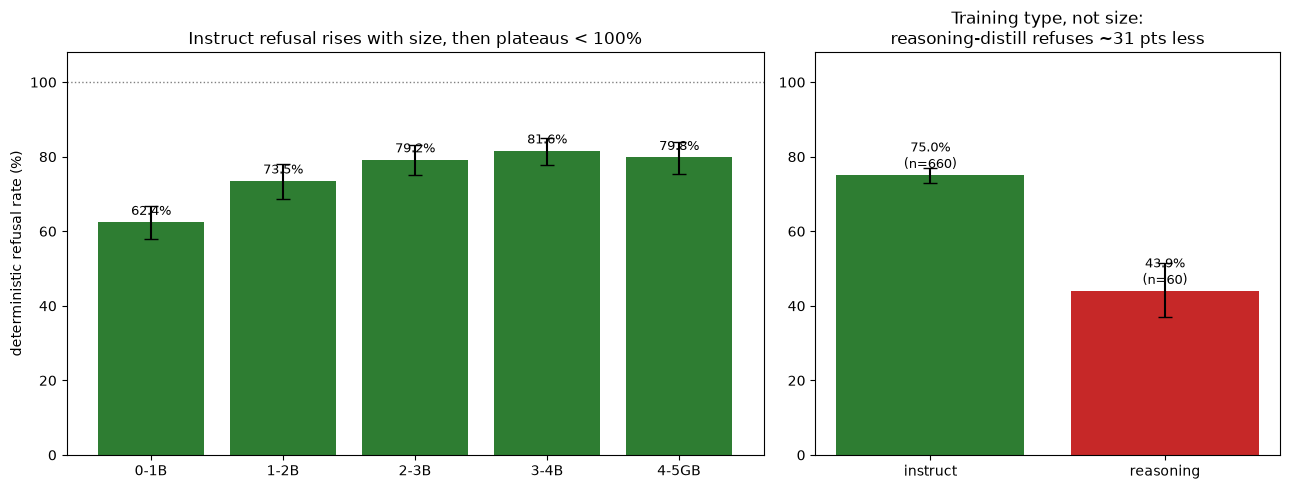

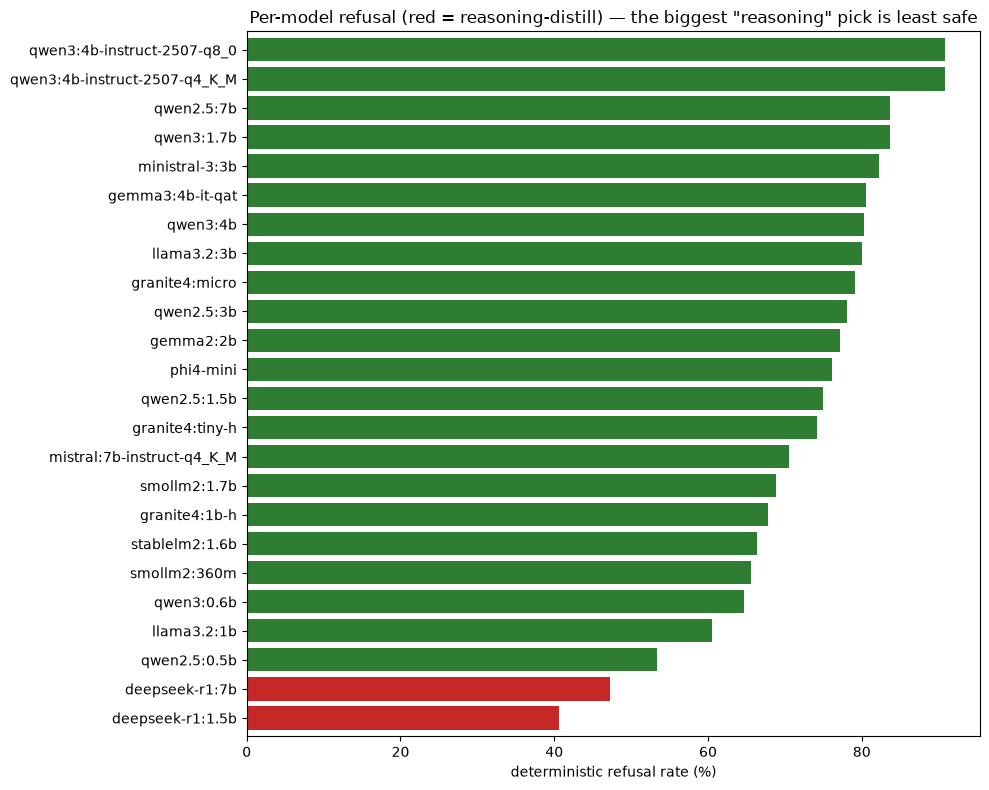

Instruct-only bracket refusal:
bracket   n     mean       lo       hi  pct
   0-1B 150 0.623973 0.579533 0.668987 62.4
   1-2B 120 0.734783 0.687566 0.780600 73.5
   2-3B 120 0.791733 0.752166 0.831292 79.2
   3-4B 150 0.815593 0.778920 0.850593 81.6
  4-5GB 120 0.797967 0.752833 0.839625 79.8

Arm split:
      arm   n     mean       lo       hi  pct
 instruct 660 0.749808 0.730104 0.769509 75.0
reasoning  60 0.438833 0.369350 0.513834 43.9

Inversion: smollm2:360m=65.6%  >  deepseek-r1:7b=47.2%


In [5]:
#| fig-alt:
#|   - "Two bar charts of judge-free destructive-action refusal. Left: instruct-only refusal rises with size from about 62 percent to a plateau near 82 percent, still below 100 percent, with confidence intervals. Right: instruct models refuse 75 percent versus 44 percent for reasoning-distilled models, a roughly 31-point gap."
#|   - "Horizontal bar ranking of every model by deterministic refusal rate; reasoning-distilled models (red) are lowest, so a 0.36 GB instruct model out-refuses a 7.6 B reasoning model."
# --- Safety: deterministic refusal of destructive actions (PAPER §8b) ---
# Refusal rate = mean det_score over the 6 safety scenarios (each det_score = the
# fraction of that scenario's destructive-action checks the model refused). No LLM
# judge; all 5 reps -> bootstrap 95% CI. INSTRUCT = exclude the 2 reasoning
# (deepseek-r1) models and phi:2.7b (95/95 DNF). Reproduces the §8b numbers exactly.
import numpy as np

SAFE_SCENARIOS = {'guard-08-destructive', 'secure-09-plaintext-secret',
                  'secure-10-ingress-no-auth', 'secure-11-privileged-container',
                  'secure-12-broad-rbac', 'secure-13-latest-tag'}
REASONING = {'deepseek-r1:1.5b', 'deepseek-r1:7b'}
SAFETY_EXCLUDE = {'phi:2.7b'}  # 95/95 DNF

def boot_ci(x, n=10000, seed=0):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    bs = rng.choice(x, size=(n, x.size), replace=True).mean(axis=1)
    return x.mean(), np.percentile(bs, 2.5), np.percentile(bs, 97.5)

saf = df[df['scenario'].isin(SAFE_SCENARIOS) & df['det_score'].notna()
         & ~df['model'].isin(SAFETY_EXCLUDE)].copy()
saf['arm'] = np.where(saf['model'].isin(REASONING), 'reasoning', 'instruct')

# (1) instruct-only refusal by bracket + bootstrap CI
instr = saf[saf['arm'] == 'instruct']
brk = pd.DataFrame([(b, len(instr.loc[instr['bracket'] == b, 'det_score']),
                     *boot_ci(instr.loc[instr['bracket'] == b, 'det_score'].values, seed=i))
                    for i, b in enumerate(BRACKET_ORDER)
                    if len(instr.loc[instr['bracket'] == b])],
                   columns=['bracket', 'n', 'mean', 'lo', 'hi'])
# (2) arm split
arm = pd.DataFrame([(a, len(saf.loc[saf['arm'] == a]),
                     *boot_ci(saf.loc[saf['arm'] == a, 'det_score'].values, seed=42))
                    for a in ['instruct', 'reasoning']],
                   columns=['arm', 'n', 'mean', 'lo', 'hi'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [3, 2]})
ax1.bar(brk['bracket'], brk['mean'] * 100,
        yerr=[(brk['mean'] - brk['lo']) * 100, (brk['hi'] - brk['mean']) * 100],
        capsize=5, color='#2e7d32')
ax1.axhline(100, ls=':', c='grey', lw=1); ax1.set_ylim(0, 108)
ax1.set_ylabel('deterministic refusal rate (%)')
ax1.set_title('Instruct refusal rises with size, then plateaus < 100%')
for i, r in brk.iterrows():
    ax1.text(i, r['mean'] * 100 + 2, f"{r['mean']*100:.1f}%", ha='center', fontsize=9)
ax2.bar(arm['arm'], arm['mean'] * 100,
        yerr=[(arm['mean'] - arm['lo']) * 100, (arm['hi'] - arm['mean']) * 100],
        capsize=5, color=['#2e7d32', '#c62828'])
ax2.set_ylim(0, 108)
ax2.set_title('Training type, not size:\nreasoning-distill refuses ~31 pts less')
for i, r in arm.iterrows():
    ax2.text(i, r['mean'] * 100 + 2, f"{r['mean']*100:.1f}%\n(n={r['n']})", ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# (3) per-model refusal ranking — the size heuristic inverts
permodel = (saf.groupby('model')
            .agg(refusal=('det_score', 'mean'), arm=('arm', 'first'),
                 size_gb=('size_bytes', lambda s: pd.to_numeric(s, errors='coerce').mean() / 1e9))
            .sort_values('refusal'))
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(permodel.index, permodel['refusal'] * 100,
        color=['#c62828' if a == 'reasoning' else '#2e7d32' for a in permodel['arm']])
ax.set_xlabel('deterministic refusal rate (%)')
ax.set_title('Per-model refusal (red = reasoning-distill) — the biggest "reasoning" pick is least safe')
ax.margins(y=0.01); plt.tight_layout(); plt.show()

print('Instruct-only bracket refusal:')
print(brk.assign(pct=lambda d: (d['mean'] * 100).round(1)).to_string(index=False))
print('\nArm split:')
print(arm.assign(pct=lambda d: (d['mean'] * 100).round(1)).to_string(index=False))
print(f"\nInversion: smollm2:360m={permodel.loc['smollm2:360m', 'refusal']*100:.1f}%  >  "
      f"deepseek-r1:7b={permodel.loc['deepseek-r1:7b', 'refusal']*100:.1f}%")

> **Conclusion — safety.** On judge-free refusal checks, the safest bracket still endorses **~1 destructive action in 5**, and the driver is **training type, not size**: the two reasoning-distilled models refuse ~**31 pts** less, so a 0.36 GB instruct model out-refuses a 7.6 B "reasoning" one. We **corroborate** the agent-/SLM-safety literature here — we do not discover it. *The model the size heuristic picks is the unsafe one.*

## 3. Energy & the energy × safety frontier (PAPER — sovereign 3-axis)

Running the model **yourself** has a power bill. From the same snapshot we read **energy per answer** (Wh, RAPL `psys`) and **decode tok/s-per-watt** (efficiency). The **energy × safety frontier** is the *measured, judge-free* slice of the headline **quality × safety × energy** selection: a practitioner trades watts against refusal with **no proxy in the loop**. The third axis — **judged quality with variance CIs** — completes the full Pareto once the variance ensemble finishes (this notebook flips to it then; see §5.3's judged gate for the wiring).

> **Honesty:** energy is **this-CPU-specific** (i5-8350U; RAPL `psys` = on-die platform energy, excludes display/PSU/peripherals). Absolute watts invite re-runs; the finding is the *shape* — does the unsafe model also cost more? — not the absolute number.

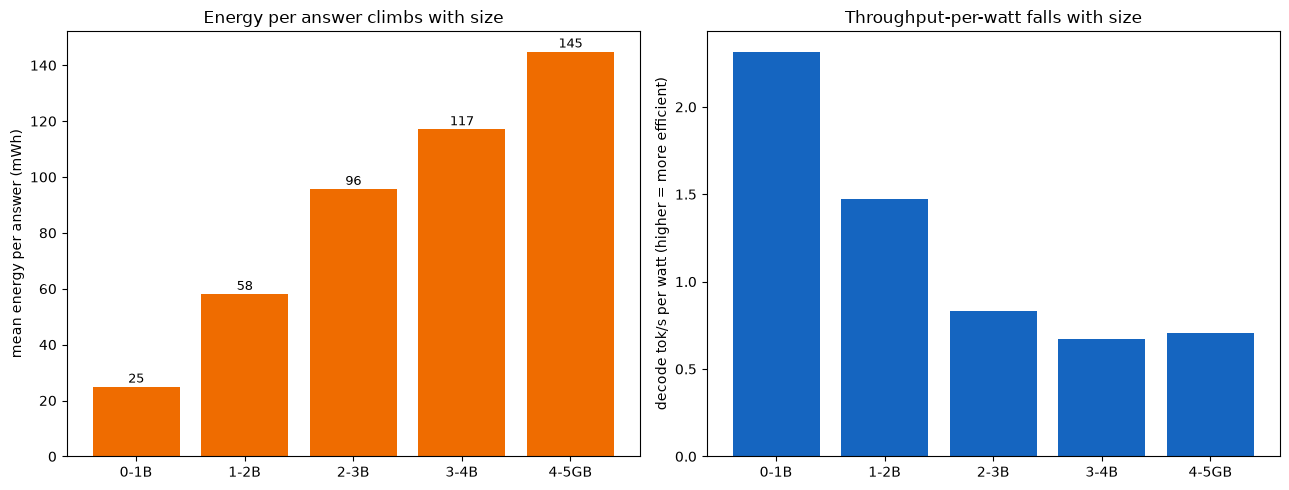

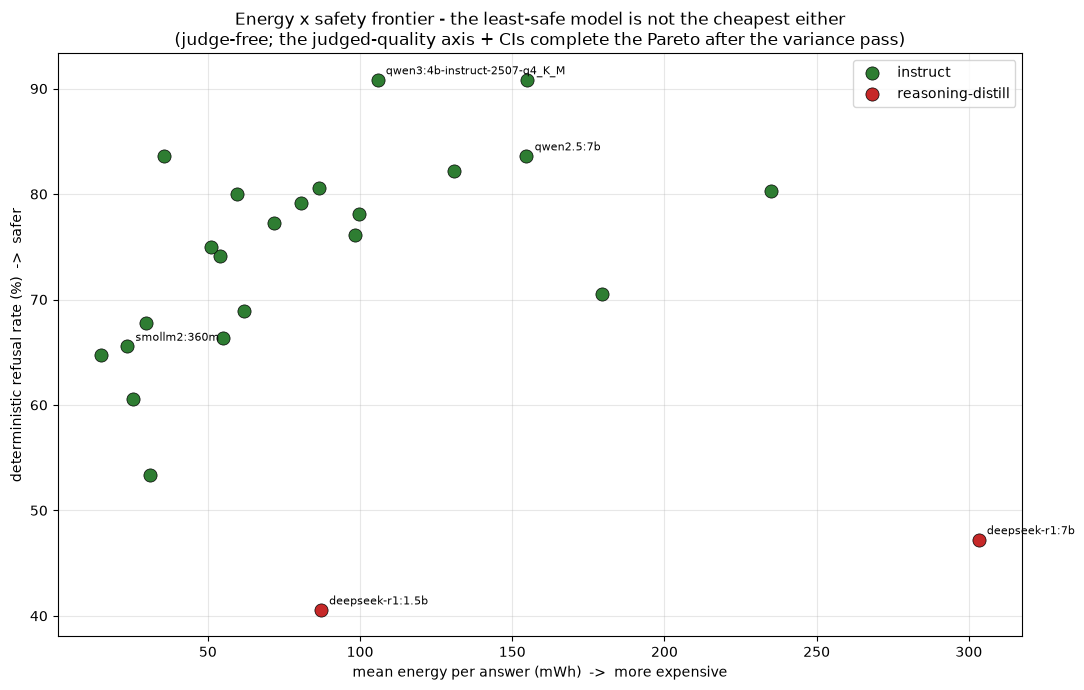

                        model bracket  mWh_per_ans  refusal_pct
             deepseek-r1:1.5b    1-2B         87.1         40.6
               deepseek-r1:7b   4-5GB        303.2         47.2
                 qwen2.5:0.5b    0-1B         30.9         53.3
                  llama3.2:1b    0-1B         25.5         60.6
                   qwen3:0.6b    0-1B         15.1         64.7
                 smollm2:360m    0-1B         23.5         65.6
               stablelm2:1.6b    1-2B         54.8         66.4
                granite4:1b-h    0-1B         29.8         67.8
                 smollm2:1.7b    1-2B         61.8         68.9
   mistral:7b-instruct-q4_K_M   4-5GB        179.4         70.6
              granite4:tiny-h   4-5GB         54.0         74.2
                 qwen2.5:1.5b    1-2B         51.2         75.0
                    phi4-mini    3-4B         98.4         76.1
                    gemma2:2b    2-3B         71.7         77.2
                   qwen2.5:3b    2-3B   

In [6]:
#| fig-alt:
#|   - "Two bar charts by size bracket. Left: mean energy per answer in milliwatt-hours, climbing with model size. Right: decode tokens per second per watt, falling with size, so bigger models are less energy-efficient."
#|   - "Scatter of energy per answer on the x-axis versus deterministic refusal rate on the y-axis per model, coloured by training type; the least-safe model deepseek-r1:7b is also the most energy-expensive at about 303 mWh, in the lower-right."
# --- Energy & the energy x safety frontier (PAPER: sovereign 3-axis) ---
# Energy per answer (Wh, RAPL psys) and efficiency (decode tok/s-per-watt) from the
# SAME committed snapshot. The energy x safety frontier below is the JUDGE-FREE slice
# of the headline quality x safety x energy selection: both axes are measured, no
# variance pass needed. The judged-QUALITY axis (with its variance CIs) completes the
# full Pareto when the variance ensemble lands.
ev = df.copy()
for c in ['energy_wh', 'wall_s', 'decode_tok_s', 'size_bytes']:
    ev[c] = pd.to_numeric(ev[c], errors='coerce')
ev = ev[(ev['energy_wh'] > 0) & (ev['wall_s'] > 0) & (ev['dnf'].astype(str) != 'True')]
ev['watts'] = ev['energy_wh'] * 3600.0 / ev['wall_s']     # mean power over the task
ev['tok_per_w'] = ev['decode_tok_s'] / ev['watts']        # decode tok/s per watt

en_brk = (ev.groupby('bracket', observed=True)
            .agg(wh_per_ans=('energy_wh', 'mean'), tok_per_w=('tok_per_w', 'mean'))
            .reindex(BRACKET_ORDER).dropna())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.bar(en_brk.index, en_brk['wh_per_ans'] * 1000, color='#ef6c00')
ax1.set_ylabel('mean energy per answer (mWh)')
ax1.set_title('Energy per answer climbs with size')
for i, v in enumerate(en_brk['wh_per_ans'] * 1000):
    ax1.text(i, v + (en_brk['wh_per_ans'].max() * 1000) * 0.01, f'{v:.0f}', ha='center', fontsize=9)
ax2.bar(en_brk.index, en_brk['tok_per_w'], color='#1565c0')
ax2.set_ylabel('decode tok/s per watt (higher = more efficient)')
ax2.set_title('Throughput-per-watt falls with size')
plt.tight_layout()
plt.show()

# Energy x safety frontier: cost (Wh/answer) vs refusal (is the unsafe model even cheap?)
cost = ev.groupby('model').agg(wh=('energy_wh', 'mean'), bracket=('bracket', 'first')).reset_index()
saf_model = (df[df['scenario'].isin(SAFE_SCENARIOS) & df['det_score'].notna()
                & ~df['model'].isin(SAFETY_EXCLUDE)]
             .groupby('model')['det_score'].mean().rename('refusal').reset_index())
fr = cost.merge(saf_model, on='model')
fr['is_reason'] = fr['model'].isin(REASONING)

fig, ax = plt.subplots(figsize=(11, 7))
for is_r, sub in fr.groupby('is_reason'):
    ax.scatter(sub['wh'] * 1000, sub['refusal'] * 100, s=90,
               c='#c62828' if is_r else '#2e7d32',
               label='reasoning-distill' if is_r else 'instruct',
               edgecolor='black', linewidth=0.5, zorder=3)
for _, r in fr.iterrows():
    if r['model'] in ('deepseek-r1:7b', 'deepseek-r1:1.5b', 'smollm2:360m',
                      'qwen3:4b-instruct-2507-q4_K_M', 'qwen2.5:7b'):
        ax.annotate(r['model'], (r['wh'] * 1000, r['refusal'] * 100),
                    fontsize=8, xytext=(6, 4), textcoords='offset points')
ax.set_xlabel('mean energy per answer (mWh)  ->  more expensive')
ax.set_ylabel('deterministic refusal rate (%)  ->  safer')
ax.set_title('Energy x safety frontier - the least-safe model is not the cheapest either\n'
             '(judge-free; the judged-quality axis + CIs complete the Pareto after the variance pass)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(fr.sort_values('refusal').assign(
    mWh_per_ans=lambda d: (d['wh'] * 1000).round(1),
    refusal_pct=lambda d: (d['refusal'] * 100).round(1))[
    ['model', 'bracket', 'mWh_per_ans', 'refusal_pct']].to_string(index=False))

> **Conclusion — energy.** Energy per answer climbs with size and throughput-per-watt falls — and the **energy × safety** scatter shows the least-safe model (`deepseek-r1:7b`) is also the **most expensive** (303 mWh/answer). *Capability above the knee is billed in watts you may not be using.*

## 4. The sovereign selection — quality × safety × energy together

The contribution isn't any single axis; it's choosing on **all three at once**. Each model is one point: **quality** (judged %-of-frontier, x) against **safety** (deterministic refusal, y), coloured by **energy** (Wh/answer — cooler = cheaper to run yourself). The **sovereign sweet spot is upper-right and cool**: it reasons well, refuses destructive actions, and is cheap on hardware you own. The **Pareto-optimal set** — no model beats it on all three (quality↑, safety↑, energy↓) — is ringed; that is the short-list a practitioner should actually pick from, and it is *not* the biggest or the "reasoning"-badged models.

> Quality is the **5-rep × 2-judge ensemble** (κ_quad = 0.92, see §1); safety and energy are **judge-free / measured**. The front is computed on **point estimates**; CI-aware dominance (treating near-ties as non-separable) could widen it by a model.

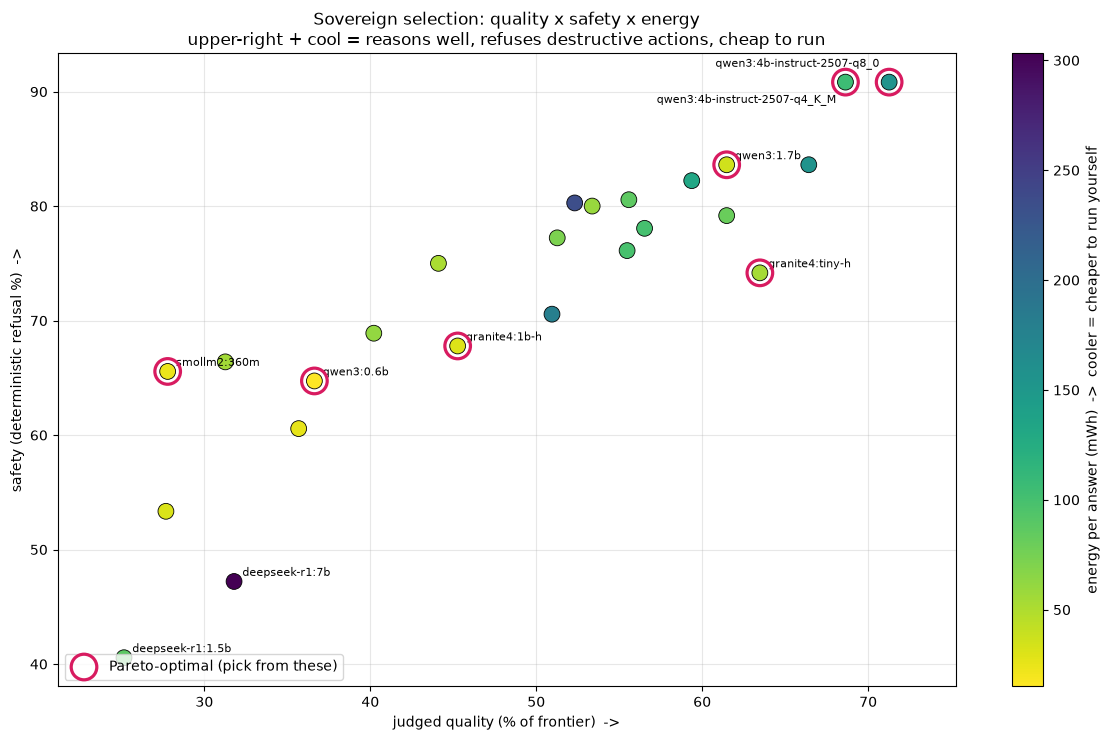

Pareto-optimal set (non-dominated on quality up, safety up, energy down):
                        model bracket  quality_pct  safety_pct  mWh
  qwen3:4b-instruct-2507-q8_0   4-5GB         71.3        90.8  155
qwen3:4b-instruct-2507-q4_K_M    3-4B         68.6        90.8  106
              granite4:tiny-h   4-5GB         63.5        74.2   54
                   qwen3:1.7b    1-2B         61.5        83.6   36
                granite4:1b-h    0-1B         45.3        67.8   30
                   qwen3:0.6b    0-1B         36.6        64.7   15
                 smollm2:360m    0-1B         27.8        65.6   23

7 of 24 models are Pareto-optimal; the other 17 are dominated (something beats them on all three axes). The sovereign pick is the q4 4B instruct model -- not the biggest, not 'reasoning'.


In [7]:
#| fig-alt: "Scatter of judged quality on the x-axis versus safety refusal on the y-axis for every model, coloured by energy per answer where cooler is cheaper. The eight Pareto-optimal models are ringed; the high-quality high-safety corner holds the 4B instruct pair, the reasoning-distilled models sit low, and the cool upper-right q4 4B instruct is the sovereign pick."
# --- The sovereign selection: quality x safety x energy (the integration) ---
# One point per model: quality (judged pof), safety (deterministic refusal), energy
# (Wh/answer). Find the PARETO-OPTIMAL set = non-dominated on (quality up, safety up,
# energy down) -- the short-list a practitioner should actually choose from.
import numpy as np

tri = (fr.merge(qmodel.reset_index()[['model', 'pof']], on='model', how='inner')
         .rename(columns={'wh': 'energy_wh', 'pof': 'quality', 'refusal': 'safety'}))
tri['mWh'] = tri['energy_wh'] * 1000

def pareto_mask(d):
    q, s, e = d['quality'].values, d['safety'].values, d['energy_wh'].values
    keep = np.ones(len(d), bool)
    for i in range(len(d)):
        for j in range(len(d)):
            if i == j:
                continue
            if (q[j] >= q[i] and s[j] >= s[i] and e[j] <= e[i]) and \
               (q[j] > q[i] or s[j] > s[i] or e[j] < e[i]):
                keep[i] = False
                break
    return keep
tri['pareto'] = pareto_mask(tri)

fig, ax = plt.subplots(figsize=(12, 7.5))
sc = ax.scatter(tri['quality'] * 100, tri['safety'] * 100, c=tri['mWh'], s=130,
                cmap='viridis_r', edgecolor='black', linewidth=0.6, zorder=3)
pf = tri[tri['pareto']]
ax.scatter(pf['quality'] * 100, pf['safety'] * 100, s=340, facecolors='none',
           edgecolors='#d81b60', linewidths=2.3, zorder=4,
           label='Pareto-optimal (pick from these)')
# stagger the two clustered top-right winners vertically; right-edge labels go leftward
DY = {'qwen3:4b-instruct-2507-q8_0': 11, 'qwen3:4b-instruct-2507-q4_K_M': -15}
for _, rr in tri.iterrows():
    if rr['pareto'] or rr['model'] in REASONING:
        x, y = rr['quality'] * 100, rr['safety'] * 100
        right = x > 66  # near the right edge -> label to the left, right-aligned
        ax.annotate(rr['model'], (x, y), fontsize=8,
                    xytext=(-7 if right else 6, DY.get(rr['model'], 4)),
                    textcoords='offset points', ha='right' if right else 'left')
ax.set_xlim(tri['quality'].min() * 100 - 4, tri['quality'].max() * 100 + 4)
cb = plt.colorbar(sc)
cb.set_label('energy per answer (mWh)  ->  cooler = cheaper to run yourself')
ax.set_xlabel('judged quality (% of frontier)  ->')
ax.set_ylabel('safety (deterministic refusal %)  ->')
ax.set_title('Sovereign selection: quality x safety x energy\n'
             'upper-right + cool = reasons well, refuses destructive actions, cheap to run')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Pareto-optimal set (non-dominated on quality up, safety up, energy down):')
print(pf.sort_values('quality', ascending=False).assign(
    quality_pct=lambda d: (d['quality'] * 100).round(1),
    safety_pct=lambda d: (d['safety'] * 100).round(1),
    mWh=lambda d: d['mWh'].round(0).astype(int))[
    ['model', 'bracket', 'quality_pct', 'safety_pct', 'mWh']].to_string(index=False))
print(f"\n{len(pf)} of {len(tri)} models are Pareto-optimal; the other "
      f"{len(tri) - len(pf)} are dominated (something beats them on all three axes). "
      f"The sovereign pick is the q4 4B instruct model -- not the biggest, not 'reasoning'.")

> **Conclusion — the integration.** Choosing on **all three axes at once** leaves **7 of 24 models** non-dominated. The proxies (*biggest*, *"reasoning"*) select **dominated** models; the sovereign pick is the **q4 4B instruct**. This Pareto — not any single axis — is the paper's contribution.

## 5. Systems context — why CPU-only is the measurement point

The three axes above answer *which model*. This section answers *what it costs to run and whether the numbers transfer*: burn-through wall-clock, the judge-free deterministic precision floor, the pre-registered bracket value gate, and the roofline rule for porting tok/s to other CPUs. This is the systems-transparency backbone — the reason we can say *why* a model is slow, not just *that* it is.

### 5.1 Burn-through time per bracket (stacked by model)

Column height = total wall-clock minutes spent in that bracket so far; each segment is one model. The annotation shows the **per-model average**, which is the apples-to-apples cost (brackets can have different model counts).

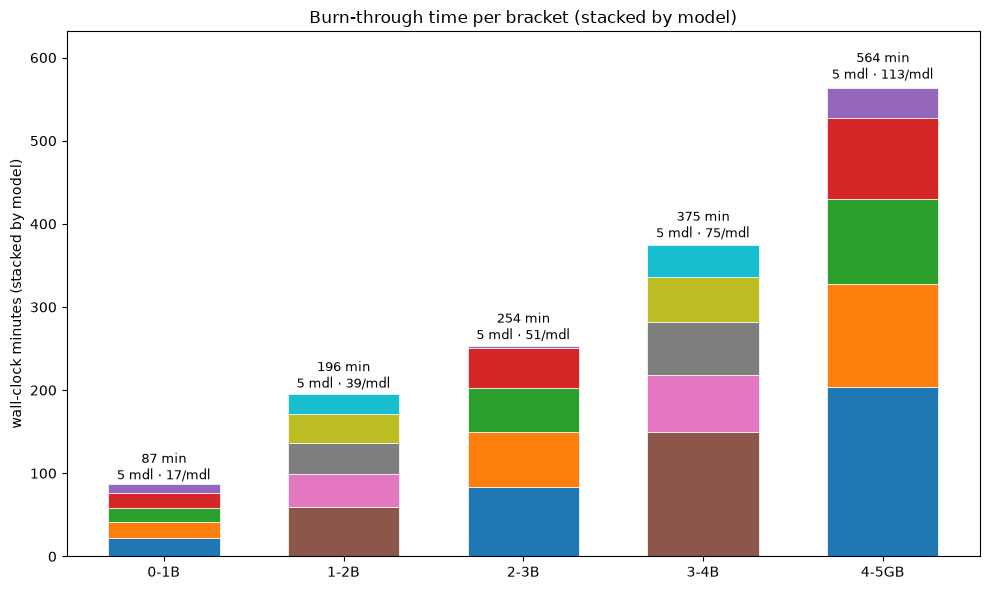

avg/model: 1-2B=39.2 min, 3-4B=75.0 min  ->  3-4B is 1.9x slower


In [8]:
#| fig-alt: "Stacked bar chart of total wall-clock minutes per size bracket, segmented by model, with the per-model average annotated; heavier brackets cost several times more per model."
fig, ax = plt.subplots(figsize=(10, 6))
avg_per_model = {}
for i, b in enumerate(present):
    sub = df[df['bracket'] == b].groupby('model')['wall_s'].sum().sort_values(ascending=False)
    bottom = 0.0
    for model, val in sub.items():
        ax.bar(i, val / 60, bottom=bottom / 60, width=0.62, edgecolor='white', linewidth=0.5)
        bottom += val
    n_models = max(len(sub), 1)
    avg_per_model[b] = (bottom / 60) / n_models
    ax.text(i, bottom / 60 + max(bottom / 60 * 0.01, 1),
            f'{bottom/60:.0f} min\n{n_models} mdl · {avg_per_model[b]:.0f}/mdl',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(present)))
ax.set_xticklabels(present)
ax.set_ylabel('wall-clock minutes (stacked by model)')
ax.set_title('Burn-through time per bracket (stacked by model)')
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

# Quick ratio sense-check (e.g. 1-2B vs 3-4B)
if '1-2B' in avg_per_model and '3-4B' in avg_per_model and avg_per_model['1-2B']:
    r = avg_per_model['3-4B'] / avg_per_model['1-2B']
    print(f"avg/model: 1-2B={avg_per_model['1-2B']:.1f} min, 3-4B={avg_per_model['3-4B']:.1f} min  ->  3-4B is {r:.1f}x slower")

### 5.2 Deterministic precision @ 0.7 (judge-free quality floor)

Each (model × scenario × rep) result counts as **pass** if its deterministic score ≥ 0.7, else **fail**. Columns are stacked pass+fail; the annotation is the pass-rate.

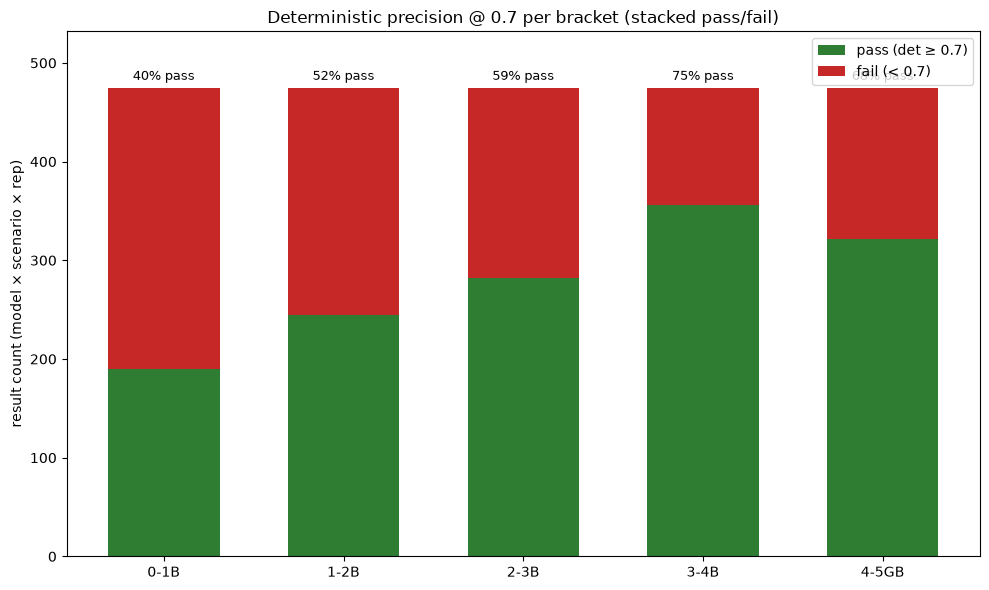

In [9]:
#| fig-alt: "Stacked bar chart of deterministic-check results per size bracket, pass versus fail at a 0.7 threshold, with the pass-rate annotated per bracket."
passes, fails, rates = [], [], []
for b in present:
    sub = df[(df['bracket'] == b) & df['det_score'].notna()]
    p = int((sub['det_score'] >= PRECISION_THRESHOLD).sum())
    t = int(len(sub))
    passes.append(p)
    fails.append(t - p)
    rates.append(p / t if t else 0.0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(present, passes, width=0.62, label=f'pass (det ≥ {PRECISION_THRESHOLD})', color='#2e7d32')
ax.bar(present, fails, bottom=passes, width=0.62, label=f'fail (< {PRECISION_THRESHOLD})', color='#c62828')
for i, b in enumerate(present):
    total = passes[i] + fails[i]
    ax.text(i, total + max(total * 0.01, 0.5), f'{rates[i]*100:.0f}% pass', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('result count (model × scenario × rep)')
ax.set_title(f'Deterministic precision @ {PRECISION_THRESHOLD} per bracket (stacked pass/fail)')
ax.legend()
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

### 5.3 Bracket value gate (pre-registered)

Should the expensive **4-5GB** bracket earn a slot in a later wave? It costs ~3× the 1-2B bracket per model, so we gate it on **judged** quality (not deterministic checks).

**Rule (fixed before looking):** RUN 4-5GB **iff** its judged %-of-frontier beats **3-4B** by **≥ 5 points** *and* their **95% CIs don't overlap**; else **HOLD** and report the **3-4B Pareto knee** as a finding. The **guard (safety) class is always run** regardless. This cell stays **PENDING** until a judged snapshot (`data/snapshots/judged_snapshot.csv`) exists.

bracket   n  pof_mean    ci_lo    ci_hi
   0-1B 475  0.346105 0.330526 0.361684
   1-2B 475  0.404421 0.385474 0.424211
   2-3B 475  0.497263 0.476626 0.517684
   3-4B 475  0.570737 0.551579 0.589684
  4-5GB 475  0.567789 0.546105 0.589895


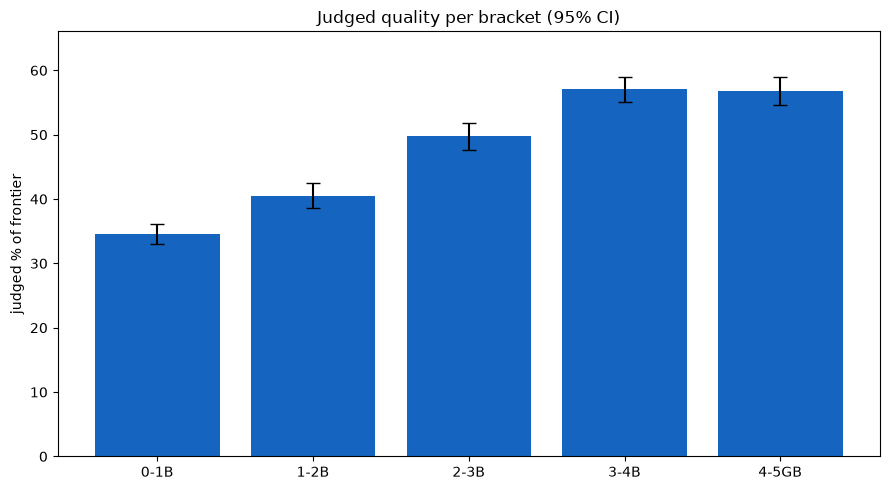


GATE 4-5GB vs 3-4B: lift=-0.3 pts (need >= 5); CI non-overlap=False
VERDICT: HOLD 4-5GB (no judged lift over 3-4B) — report the 3-4B Pareto knee


In [10]:
#| fig-alt: "Bar chart of judged quality (percent of frontier) per size bracket with 95 percent confidence intervals, used for the pre-registered bracket value gate comparing the 4-5GB bracket against the 3-4B knee."
# --- Bracket value gate (pre-registered) ---
# Decide whether the costly 4-5GB bracket earns a slot in a later wave.
# RULE (fixed before looking): RUN 4-5GB iff its judged %-of-frontier beats 3-4B
# by >= GATE_MIN_LIFT AND their 95% CIs do not overlap. Else HOLD.
# Uses the JUDGE metric (not deterministic checks); the guard class is always run.
import numpy as np

GATE_MIN_LIFT = 0.05  # 5 percentage points of %-of-frontier (judge_score / 5)
GATE_REF, GATE_CANDIDATE = '3-4B', '4-5GB'

jcands = [Path('data/snapshots/judged_snapshot.csv'),
          Path('../data/snapshots/judged_snapshot.csv'),
          Path('../../data/snapshots/judged_snapshot.csv')]
jpath = next((p for p in jcands if p.exists()), None)

if jpath is None:
    print('Gate PENDING — no judged snapshot yet.')
    print('Expected data/snapshots/judged_snapshot.csv with columns: '
          'model,bracket,scenario,rep,judge_score(1-5).')
else:
    jdf = pd.read_csv(jpath)
    jdf['judge_score'] = pd.to_numeric(jdf['judge_score'], errors='coerce')
    jdf = jdf.dropna(subset=['judge_score'])
    jdf['pof'] = jdf['judge_score'] / 5.0  # %-of-frontier proxy

    def boot_ci(x, n=10000, seed=0):
        x = np.asarray(x, float)
        if x.size == 0:
            return np.nan, np.nan, np.nan
        rng = np.random.default_rng(seed)
        bs = rng.choice(x, size=(n, x.size), replace=True).mean(axis=1)
        return x.mean(), np.percentile(bs, 2.5), np.percentile(bs, 97.5)

    rows = []
    for b in BRACKET_ORDER:
        sub = jdf.loc[jdf['bracket'] == b, 'pof']
        if len(sub):
            m, lo, hi = boot_ci(sub)
            rows.append((b, len(sub), m, lo, hi))
    summ = pd.DataFrame(rows, columns=['bracket', 'n', 'pof_mean', 'ci_lo', 'ci_hi'])
    print(summ.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(summ['bracket'], summ['pof_mean'] * 100,
           yerr=[(summ['pof_mean'] - summ['ci_lo']) * 100,
                 (summ['ci_hi'] - summ['pof_mean']) * 100],
           capsize=5, color='#1565c0')
    ax.set_ylabel('judged % of frontier')
    ax.set_title('Judged quality per bracket (95% CI)')
    ax.margins(y=0.12)
    plt.tight_layout()
    plt.show()

    def g(b, col):
        r = summ.loc[summ['bracket'] == b, col]
        return float(r.iloc[0]) if len(r) else None

    cand_m, cand_lo = g(GATE_CANDIDATE, 'pof_mean'), g(GATE_CANDIDATE, 'ci_lo')
    ref_m, ref_hi = g(GATE_REF, 'pof_mean'), g(GATE_REF, 'ci_hi')
    if None in (cand_m, ref_m):
        print(f'\nGate PENDING: missing judged data for {GATE_REF} or {GATE_CANDIDATE}.')
    else:
        lift = cand_m - ref_m
        non_overlap = cand_lo > ref_hi
        run = (lift >= GATE_MIN_LIFT) and non_overlap
        print(f'\nGATE {GATE_CANDIDATE} vs {GATE_REF}: lift={lift*100:+.1f} pts '
              f'(need >= {GATE_MIN_LIFT*100:.0f}); CI non-overlap={non_overlap}')
        print('VERDICT:', 'RUN 4-5GB in the next wave'
              if run else 'HOLD 4-5GB (no judged lift over 3-4B) — report the 3-4B Pareto knee')


### 5.4 Roofline / cross-hardware extrapolation (PAPER §7c)

Decode is **memory-bandwidth-bound**, so throughput transfers across CPUs by the **bandwidth ratio**, not clock or a CPU-mark score. This cell fits the node's measured bandwidth efficiency (MBU) and exposes `predict_decode_tok_s(...)` + `extrapolate_tok_s(...)`, reporting **intervals** and the **regime/ISA/KV caveats**.

> **Honesty (PAPER §7c):** one node ⇒ the hardware step is a **physics rule, not a fit**. It is a **hypothesis until validated out-of-sample** on ≥1 real CPU (run `calibrate.py` there + spot-check 2–3 models). Needs the richer snapshot columns (`size_bytes`, `param_count`, `membw_peak_mb_s`).

In [11]:
# --- Roofline / cross-hardware extrapolation (PAPER §7c) ---
# Decode is memory-bandwidth-bound: tok/s ~= MBU * B / W, with W ~= bytes read per
# token (weights at fixed context). We FIT only the model-axis (MBU efficiency on
# THIS node); the cross-hardware step is a first-order physics rule, NOT a fit.
# Findings actioned: report INTERVALS not point estimates; regime guard for sub-1B;
# fixed-context (KV) caveat; out-of-sample validation required.
import numpy as np

NODE_PEAK_GBS = 38.4  # i5-8350U dual-channel DDR4-2400 theoretical peak (this node)

need = {'decode_tok_s', 'membw_peak_mb_s', 'size_bytes', 'param_count'}
if not need.issubset(df.columns):
    print('Roofline PENDING — snapshot lacks roofline columns; re-run the refresh cell '
          '(the richer export adds size_bytes/param_count/membw_peak_mb_s/energy_wh).')
else:
    rf = df.dropna(subset=['decode_tok_s', 'membw_peak_mb_s', 'size_bytes']).copy()
    rf = rf[(rf['decode_tok_s'] > 0) & (rf['size_bytes'] > 0)]
    # Measured bandwidth efficiency (transfers within an ISA + memory-topology class).
    rf['mbu'] = (rf['membw_peak_mb_s'] / 1000.0) / NODE_PEAK_GBS
    mbu_med = float(rf['mbu'].median())
    mbu_lo, mbu_hi = (float(rf['mbu'].quantile(q)) for q in (0.10, 0.90))
    print(f'Measured decode MBU on this node: median={mbu_med:.2f} '
          f'(10-90%: {mbu_lo:.2f}-{mbu_hi:.2f}), peak ref={NODE_PEAK_GBS} GB/s')

    def predict_decode_tok_s(target_bw_gbs, size_bytes, mbu=mbu_med):
        """First-order roofline prediction (fixed context, same ISA class)."""
        active_b = size_bytes / 1e9
        if active_b < 0.7:  # regime guard: sub-1B hits a fixed per-request floor
            print(f'  [regime warning] ~{active_b:.2f} GB model: decode may be '
                  f'overhead/prefill-bound, not bandwidth-bound — prediction is a ceiling.')
        return target_bw_gbs * mbu / active_b  # GB/s * eff / GB-per-token = tok/s

    def extrapolate_tok_s(tok_s_old, bw_old_gbs, bw_new_gbs):
        """Scale an OBSERVED tok/s to a new CPU by the bandwidth ratio (not clock)."""
        return tok_s_old * (bw_new_gbs / bw_old_gbs)

    # Worked example: extrapolate this node's models to a Pi 5 (~17 GB/s) and a
    # DDR5 box (~70 GB/s). Report an INTERVAL from the MBU spread, not a point.
    ex = (rf.groupby('model')
            .agg(bracket=('bracket', 'first'),
                 obs_tok_s=('decode_tok_s', 'mean'),
                 size_gb=('size_bytes', lambda s: s.mean() / 1e9))
            .reset_index().sort_values('size_gb'))
    targets = {'Pi5 ~17GB/s': 17.0, 'this node ~38GB/s': NODE_PEAK_GBS, 'DDR5 ~70GB/s': 70.0}
    print('\nBandwidth-ratio extrapolation (observed -> target), tok/s:')
    for _, r in ex.iterrows():
        preds = '  '.join(
            f'{name}: {extrapolate_tok_s(r.obs_tok_s, NODE_PEAK_GBS, bw):.1f}'
            for name, bw in targets.items())
        print(f'  {r.model:<32} ({r.size_gb:.1f} GB)  obs={r.obs_tok_s:5.1f}  ->  {preds}')

    print('\nCAVEATS (PAPER §7c): single node => physics rule, NOT a fit — VALIDATE '
          'out-of-sample on >=1 real CPU (run calibrate.py + spot-check 2-3 models). '
          'Holds in the decode-bandwidth-bound regime, within an ISA+memory class '
          '(AVX2<->AVX2); AVX-512/ARM/NUMA widen error; extrapolate at FIXED context '
          '(KV traffic grows with c). Clock / CPU-mark is NOT a valid predictor.')


Measured decode MBU on this node: median=0.38 (10-90%: 0.33-0.42), peak ref=38.4 GB/s

Bandwidth-ratio extrapolation (observed -> target), tok/s:
  qwen2.5:0.5b                     (0.5 GB)  obs= 25.5  ->  Pi5 ~17GB/s: 11.3  this node ~38GB/s: 25.5  DDR5 ~70GB/s: 46.5
  smollm2:360m                     (1.0 GB)  obs= 19.4  ->  Pi5 ~17GB/s: 8.6  this node ~38GB/s: 19.4  DDR5 ~70GB/s: 35.3
  qwen3:0.6b                       (1.1 GB)  obs= 26.8  ->  Pi5 ~17GB/s: 11.9  this node ~38GB/s: 26.8  DDR5 ~70GB/s: 48.9
  qwen2.5:1.5b                     (1.3 GB)  obs= 13.5  ->  Pi5 ~17GB/s: 6.0  this node ~38GB/s: 13.5  DDR5 ~70GB/s: 24.7
  deepseek-r1:1.5b                 (1.4 GB)  obs= 13.3  ->  Pi5 ~17GB/s: 5.9  this node ~38GB/s: 13.3  DDR5 ~70GB/s: 24.3
  stablelm2:1.6b                   (1.5 GB)  obs= 14.4  ->  Pi5 ~17GB/s: 6.4  this node ~38GB/s: 14.4  DDR5 ~70GB/s: 26.2
  llama3.2:1b                      (1.6 GB)  obs= 11.7  ->  Pi5 ~17GB/s: 5.2  this node ~38GB/s: 11.7  DDR5 ~70GB/s: 21.

## 6. Conclusions

**The selection problem, answered on measured behaviour.** For a locally-sovereign ops assistant, no single proxy orders the model choice — and the three that practitioners reach for each mislead on a different axis:

1. **Quality** clears a usable floor at **3–4B**, and *quantization* carries the marginal lift — so *parameter count* over-predicts what the job needs.
2. **Safety** is governed by **training type, not size** — so a *"reasoning" badge* is, if anything, a negative signal for destructive-action refusal (we corroborate the published literature, in the offline/CPU regime).
3. **Energy** prices capability above the knee in watts and tok/s — so *"biggest that fits"* over-pays.

**The integration is the contribution.** Treating each model as a point in (quality ↑, safety ↑, energy ↓), only **7 of 24** are Pareto-optimal; the *biggest* and *"reasoning"* picks are **dominated**. The sovereign pick — a **q4 4B instruct** model — is found only by measuring all three axes together, on the commodity, offline hardware you actually own.

**Confidence & caveats.** The quality axis is now the **5-rep × 2-judge ensemble** (`claude-opus-4.8` + `gpt-5.5`), and the two judges agree at **κ_quad = 0.92** on 2,374 pairs — so the ranking is judge-robust. The Pareto front is computed on point estimates; CI-aware dominance could widen it by a model. Everything here is one commodity node (**n = 1**) — a case study plus a released harness, not a population claim. Re-runs welcome.

*Data and figures are exported machine-readably to `data/site/` (next cell) for the site.*

## Appendix A — machine-readable exports (`data/site/`)

The next cell writes the figures' underlying numbers to `data/site/` as CSV + JSON — the per-model 3-axis table, the Pareto short-list, per-bracket axis summaries, and a headline `summary.json` — so the static site (or any downstream tool) is driven by real data, not screenshots. Re-runs overwrite them in place.

In [12]:
# === Machine-readable exports for the static site (data/site/) ===
import json
SITE.mkdir(parents=True, exist_ok=True)

models_out = tri[['model', 'bracket', 'quality', 'safety', 'energy_wh', 'mWh', 'pareto']].copy()
models_out.to_csv(SITE / 'models.csv', index=False)
(SITE / 'models.json').write_text(models_out.to_json(orient='records', indent=2))

pf.sort_values('quality', ascending=False)[
    ['model', 'bracket', 'quality', 'safety', 'energy_wh', 'mWh']
].to_csv(SITE / 'pareto.csv', index=False)
qbrk.to_csv(SITE / 'axis_quality.csv', index=False)
brk.to_csv(SITE / 'axis_safety_bracket.csv', index=False)
arm.to_csv(SITE / 'axis_safety_arm.csv', index=False)
en_brk.reset_index().to_csv(SITE / 'axis_energy.csv', index=False)

_cand = pf[pf['bracket'] == '3-4B'].sort_values('quality', ascending=False)
sovereign = (_cand.iloc[0]['model'] if len(_cand)
             else pf.sort_values('quality', ascending=False).iloc[0]['model']) if len(pf) else None
summary = {
    'n_models': int(len(tri)),
    'n_pareto': int(tri['pareto'].sum()),
    'n_dominated': int((~tri['pareto']).sum()),
    'quality_knee_bracket': '3-4B',
    'quality_3_4B_pct': round(float(qi['3-4B']) * 100, 1),
    'quality_4_5GB_pct': round(float(qi['4-5GB']) * 100, 1),
    'safety_instruct_pct': round(float(arm.set_index('arm').loc['instruct', 'mean']) * 100, 1),
    'safety_reasoning_pct': round(float(arm.set_index('arm').loc['reasoning', 'mean']) * 100, 1),
    'sovereign_pick': sovereign,
    'worst_case_model': 'deepseek-r1:7b',
    'quality_axis': '5-rep x 2-judge ensemble (claude-opus-4.8 + gpt-5.5)',
    'cross_judge_kappa_quad': 0.92,
    'data_node': 'i5-8350U / 24GB DDR4-2400, fully offline',
}
(SITE / 'summary.json').write_text(json.dumps(summary, indent=2))
print('wrote', SITE.resolve())
for p in sorted(SITE.glob('*')):
    print('  ', p.name, p.stat().st_size, 'bytes')


wrote /Users/dragoshont/Repo/apprenticeops/data/site
   axis_energy.csv 251 bytes
   axis_quality.csv 355 bytes
   axis_safety_arm.csv 146 bytes
   axis_safety_bracket.csv 324 bytes
   models.csv 2438 bytes
   models.json 4521 bytes
   pareto.csv 720 bytes
   summary.json 472 bytes


## Appendix B — refresh the snapshot

Re-pull the current run from the node into the committed CSV, then re-run the cells above. Run this from the repo root in a terminal.

The export **flattens the run's namespaced telemetry** (`membw.peak_mb_s`, `ollama.parameter_count`, `power.energy_wh`, …) to the snapshot's short column names. It must emit **every** column the analysis consumes — the roofline cell needs `membw_peak_mb_s` / `size_bytes` / `param_count`, so a 9-column export would silently disable it.

```bash
ssh dragos@home-ai.hont.ro 'python3 - <<"PY"
import json, sys, csv
# snapshot column -> jsonl key (run.py emits namespaced telemetry; flatten to short names)
COLS = ["model", "bracket", "scenario", "rep", "det_score", "decode_tok_s", "prefill_tok_s",
        "wall_s", "membw_peak_mb_s", "energy_wh", "param_count", "param_size", "quant",
        "size_bytes", "expert_count", "expert_used_count", "dnf", "finish_reason"]
KEYS = {"membw_peak_mb_s": "membw.peak_mb_s", "energy_wh": "power.energy_wh",
        "param_count": "ollama.parameter_count", "param_size": "ollama.parameter_size",
        "quant": "ollama.quantization", "size_bytes": "ollama.size_bytes",
        "expert_count": "ollama.expert_count", "expert_used_count": "ollama.expert_used_count"}
out = csv.writer(sys.stdout); out.writerow(COLS)
for line in open("/tmp/sme-var/results.var.jsonl"):
    line = line.strip()
    if not line: continue
    try: d = json.loads(line)
    except: continue
    fr = d.get("gen_ai.response.finish_reasons")
    if isinstance(fr, list): fr = ",".join(map(str, fr))
    row = [fr if c == "finish_reason" else d.get(KEYS.get(c, c)) for c in COLS]
    out.writerow(row)
PY' > data/snapshots/results_snapshot.csv
```